# Task 2: CNN Training for pixel-wise classification

In this task you will be provided a model that was pretrained on [BigEarthNet v2](https://arxiv.org/abs/1902.06148) for pixel-wise classification (i.e. semantic segmentation). We will provide you with a checkpoint, as well as the model definition and your task is to load that model using these weights and finetune it on our target domain (forest segmentation) in our target location (Amazon Rainforest) with pytorch lightning. For that we will provide you with a finetuning dataset.

<img src="../../../data/Example_finetune.png" alt="Example from Dataset" width="600"/>


The goals of this task are as follows:
1. Load a pretrained pixelwise segmentation model
2. Adapt and finetune the model on a new domain (forest segmentation) and location (Amazon Rain Forest)

## Imports

These are all imports we used when solving the task. Please leave them as is even though you might not need all of them.

In [1]:
import os
import rootutils
root = rootutils.setup_root(os.path.abspath(''), dotenv=True, pythonpath=True, cwd=False)

data_path = root / "data"
data_path.mkdir(exist_ok=True)
output_dir = root / "output"
output_dir.mkdir(exist_ok=True)


In [2]:
import torch
from types import SimpleNamespace
from huggingface_hub import PyTorchModelHubMixin
import lightning as L
from configilm import ConfigILM # see https://lhackel-tub.github.io/ConfigILM/ for more information
from torchinfo import summary

from torchmetrics.segmentation import MeanIoU
import torch.nn as nn
import torch.nn.functional as F

import lmdb
from torch.utils.data import Dataset, DataLoader, random_split
from safetensors.numpy import load as load_np_safetensor
import torchvision.transforms as transforms

from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import random

## 2.1 Dataset + DataModule definition

Before we can use our data we need to wrap it in a pytorch dataset and thereafter in a lightning DataModule so we can use it for model training. 

### Dataset

For efficient data loading we have put the images in the file `images.lmdb` and the segmentation masks (forest/ no forest) in the file `mask.lmdb`. [LMDB](http://www.lmdb.tech/doc/) is a key-value in-memory database. For the images the key is the image name (1.tif, 2.tif,...) and the values are the image pixels as safetensor (Tip: use `load_np_safetensor` to read it). For the masks the key is the image name followed by _mask (1_mask.tif, 2_mask.tif, ...) the value again is the pixels as safetensor (1 for forest, 0 for no forest). We provided the helper function `_open_lmdb` which opens a connection to the lmdb for images or masks if it does not exist yet. You can read data from the lmdb through `with self.env_images.begin() as txn: txn.get()`. Feel free to add additional functions and adapt the already existing ones. Please open the lmdb only in the `__getitem__` method, due to multi processing.
Use preprocessing and data augmentation where applicable.

In [3]:
mean =  [438.37207031, 614.05566406, 588.40960693, 2193.29199219, 942.84332275, 1769.93164062, 2049.55151367, 1568.22680664, 997.73248291, 2235.55664062]
std = [607.02685547, 603.29681396, 684.56884766, 1369.3717041, 738.43267822, 1100.45605469, 1275.80541992, 1070.16125488, 813.52764893, 1356.54406738]


class FinetuneDataset(Dataset):
    def __init__(self, images_lmdb_path=data_path / "images.lmdb", masks_lmdb_path=data_path / "mask.lmdb", transform=None):
        self.images_lmdb_path = images_lmdb_path
        self.masks_lmdb_path = masks_lmdb_path

        self.env_images = None
        self.env_masks = None
        self.transform = transform


    def _open_lmdb(self, env, path):
        # If the environment is already opened, simply return it
        if env is not None:
            return env
    
        # The path must be a nonempty string
        if not path:
            raise ValueError("The LMDB path is not set")
    
        # Attempt to open the environment; if it fails, rewrap the exception
        try:
            return lmdb.open(str(path), readonly=True, lock=False)
        except lmdb.Error as e:
            raise RuntimeError(f"Failed to open LMDB at {path!r}") from e


    def __len__(self):
        if self.env_images is None:
            self.env_images = self._open_lmdb(self.env_images, self.images_lmdb_path)

        with self.env_images.begin() as txn:
            length = txn.stat()['entries']
        return length

    def __getitem__(self, idx):
        # should return image, mask
        self.env_images = self._open_lmdb(self.env_images, self.images_lmdb_path)
        self.env_masks = self._open_lmdb(self.env_masks, self.masks_lmdb_path)

        image_key = f"{idx}.tif".encode('utf-8')
        mask_key = f"{idx}_mask.tif".encode('utf-8')

        with self.env_images.begin() as txn:
            image_data = txn.get(image_key)
            if image_data is None:
                raise KeyError(f"Image with index {idx} not found.")
            image = load_np_safetensor(image_data) # image is a Dict[key:str, np.ndarray]
            image = list(image.values())[0]
        with self.env_masks.begin() as txn:
            mask_data = txn.get(mask_key)
            if mask_data is None:
                raise KeyError(f"Mask with index {idx} not found.")
            mask = load_np_safetensor(mask_data)
            mask = list(mask.values())[0]

        image = torch.from_numpy(image).to(torch.float32)
        mask = torch.from_numpy(mask).to(torch.float32)        
    
        # Augmentation & Normalization
        image, mask = do_random_augmentation(image, mask)
        image = (image - torch.tensor(mean).view(-1, 1, 1)) / torch.tensor(std).view(-1, 1, 1)

        return image, mask

def do_random_augmentation(image, mask):
    # Horizontal flip
    if torch.rand(1).item() > 0.5:
        image = torch.flip(image, dims=[2])
        mask = torch.flip(mask, dims=[2]) 
    # Vertical flip
    if torch.rand(1).item() > 0.5:
        image = torch.flip(image, dims=[1])
        mask = torch.flip(mask, dims=[1])

    return image, mask

### DataModule

Your DataModule needs to return a valid dataloader for training, validation and testing. Implement the [pytorch lighting](https://lightning.ai/docs/pytorch/stable/) training procedure.

In [4]:
class FinetuneDataModule(L.LightningDataModule):
    def __init__(self, images_lmdb_path=data_path / "images.lmdb", masks_lmdb_path=data_path / "mask.lmdb", batch_size=16, num_workers=0,
                 train_val_test_split=[0.8, 0.1, 0.1]):
        super().__init__()
        self.images_lmdb_path = images_lmdb_path
        self.masks_lmdb_path = masks_lmdb_path
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.train_val_test_split = train_val_test_split

    def setup(self, stage=None):
        dataset_full = FinetuneDataset(images_lmdb_path=self.images_lmdb_path, masks_lmdb_path=self.masks_lmdb_path)
        self.data_train, self.data_val, self.data_test = random_split(dataset_full, self.train_val_test_split, generator=torch.Generator().manual_seed(42))

    def train_dataloader(self):
        return DataLoader(self.data_train, batch_size=self.batch_size, shuffle=True, num_workers=self.num_workers)

    def val_dataloader(self):
        return DataLoader(self.data_val, batch_size=self.batch_size, num_workers=self.num_workers)

    def test_dataloader(self):
        return DataLoader(self.data_test, batch_size=self.batch_size, num_workers=self.num_workers)

## 2.2 Model Definition

In the following we provide you with the definition for a pretrained Resnet18 (pretrained on BigEarthNet). After we have given you an adaptation of the architecture to be used for semantic segmentation. You need to complete the rest of the required model setup.

### BEN pretrained Resnet18

Here we provide you with the definition of a Resnet18 model pretrained on BEN.

In [5]:
class Resnet(L.LightningModule, PyTorchModelHubMixin):
    def __init__(self, config):
        super().__init__()
        self.config = SimpleNamespace(**config)
        self.model = ConfigILM.ConfigILM(self.config)

    def forward(self, x):
        return self.model(x)

### Fully convolutional adaptation

We have only defined the bare minimum (architecture + forward pass). You need to fill in the rest and add functions were appropriate so the model can be used for training later on. As evaluation metric you can use mean Intersection over Union (mIoU). Have a look at [mIoU](https://lightning.ai/docs/torchmetrics/stable/segmentation/mean_iou.html) imported above. Implement the [pytorch lighting](https://lightning.ai/docs/pytorch/stable/) training steps.

In [6]:
pretrained_model  = Resnet.from_pretrained("BIFOLD-BigEarthNetv2-0/resnet18-s2-v0.2.0").model.vision_encoder
backbone = nn.Sequential(*list(pretrained_model.children())[:-2])

class FCNResnet(L.LightningModule):
    def __init__(self, num_classes=19, learning_rate=1e-4, weight_decay=1e-4, T_max=5, eta_min=1e-4/50):
        super().__init__()
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.T_max = T_max
        self.eta_min = eta_min
        self.num_classes = num_classes
        self.mIoU = MeanIoU(num_classes=num_classes)
        self.val_outputs = []
        self.test_outputs = []

        self.backbone = backbone

        # Upsample the encoded input to the size of the image.
        self.decoder = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),

            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),

            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),

            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(size=(120,120), mode='bilinear', align_corners=False),

            nn.Conv2d(32, num_classes, kernel_size=1)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.decoder(x)

        return x

    def training_step(self, batch, batch_idx):
        imgs, labels = batch
        labels = labels.squeeze(1).long() 
        preds = self(imgs)
        preds = torch.nn.functional.interpolate(preds, size=labels.shape[1:], mode='bilinear', align_corners=False)
        loss = F.cross_entropy(preds, labels)
        miou = self.mIoU(preds.argmax(dim=1), labels)

        self.log("train_miou", miou, on_step=False, on_epoch=True)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        imgs, labels = batch
        labels = labels.squeeze(1).long() 
        preds = self(imgs)
        preds = torch.nn.functional.interpolate(preds, size=labels.shape[1:], mode='bilinear', align_corners=False)
        loss = F.cross_entropy(preds, labels)
        miou = self.mIoU(preds.argmax(dim=1), labels)
        
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_miou", miou, prog_bar=True)

    def test_step(self, batch, batch_idx):
        imgs, labels = batch
        labels = labels.squeeze(1).long() 
        preds = self(imgs)
        preds = torch.nn.functional.interpolate(preds, size=labels.shape[1:], mode='bilinear', align_corners=False)
        miou = self.mIoU(preds.argmax(dim=1), labels)
        self.log("test_miou", miou)

    def configure_optimizers(self):
        # code taken from Lab05
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay)
        lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=self.T_max, eta_min=self.eta_min)
        return [optimizer], [lr_scheduler]

/mnt/c/Users/binhp/Desktop/Studium/Master/Semester 01/IPL4EO/ipl4eo-dependencies/ipl4eo_miniproject_2025/.venv/lib/python3.12/site-packages/configilm/ConfigILM.py:134: UserWarning: Keyword 'img_size' unknown. Trying to ignore and restart creation.
  warnings.warn(f"Keyword '{failed_kw}' unknown. Trying to ignore and restart creation.")


## 2.3 Finetuning

Please write the logic required for finetuning the model using the DataModule you have defined above. The checkpoint is the one provided by us finetuned on segmentation for BigEarthNet. Adapt the model if necessary. Briefly describe the results.


In [7]:
# Parameters
ckpt_path = data_path / "pretrained_model.ckpt"
seed = 42
lr = 5e-4
weight_decay = 1e-4
T_max = 15
eta_min = (5e-4)/50
train_val_test_split = [0.7, 0.15, 0.15]
batch_size = 16
patience = 10

# Seed for reproducibility
L.pytorch.seed_everything(seed, workers=True)

# Initialize model & prepare data
model = FCNResnet.load_from_checkpoint(checkpoint_path=ckpt_path, learning_rate=lr, weight_decay=weight_decay, T_max=T_max, eta_min=eta_min)
data_module = FinetuneDataModule(batch_size=batch_size, num_workers=7, train_val_test_split=train_val_test_split)

# Set up trainer & learn model
checkpoint_callback = ModelCheckpoint(monitor="val_miou", mode="max", save_top_k=1, filename="best_learned_model")
early_stopping = EarlyStopping(monitor='val_miou', mode="max", patience=patience)
logger = CSVLogger("logs", name="task2_model")
trainer = L.pytorch.Trainer(deterministic=True, accelerator="auto", max_epochs=100, callbacks=[checkpoint_callback, early_stopping], logger=logger)
trainer.fit(model=model, train_dataloaders=data_module)

# Determine in which epoch best model has been learned
log_dir = logger.log_dir + "/metrics.csv"
df = pd.read_csv(log_dir)
epochs_data = df[["epoch", "val_loss", "val_miou"]].dropna(subset=["val_loss", "val_miou"])
best_row = epochs_data.loc[epochs_data["val_miou"].idxmax()]
best_epoch = int(best_row["epoch"])
best_miou = best_row["val_miou"]
print(f"Early stopping after {len(epochs_data["epoch"])} epochs with best epoch in {best_epoch} with Validation mIoU {best_miou}")

Seed set to 42
/mnt/c/Users/binhp/Desktop/Studium/Master/Semester 01/IPL4EO/ipl4eo-dependencies/ipl4eo_miniproject_2025/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.5.1.post0, which is newer than your current Lightning version: v2.5.1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name     | Type       | Params | Mode 
------------------------------------------------
0 | mIoU     | MeanIoU    | 0      | train
1 | backbone | Sequential | 11.2 M | train
2 | decoder  | Sequential | 1.6 M  | train
------------------------------------------------
12.8 M    Trainable params
0         Non-trainable params
12.8 M    Total params
51.065    Total estimated model params size (MB)
112       Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                | 0/? [00:00…

Training: |                                                                                       | 0/? [00:00…

Validation: |                                                                                     | 0/? [00:00…

Validation: |                                                                                     | 0/? [00:00…

...

Validation: |                                                                                     | 0/? [00:00…

Validation: |                                                                                     | 0/? [00:00…

Validation: |                                                                                     | 0/? [00:00…

Validation: |                                                                                     | 0/? [00:00…

Early stopping after 28 epochs with best epoch in 17 with Validation mIoU 0.7381599545478821


In [8]:
#Show Val loss and val miou over the epochs
print(epochs_data)

     epoch  val_loss  val_miou
5        0  0.246689  0.695068
12       1  0.798412  0.089095
19       2  0.275047  0.693785
26       3  0.340689  0.680523
33       4  0.751736  0.154268
40       5  0.305546  0.708103
47       6  1.153588  0.213058
55       7  0.221921  0.720289
62       8  0.300423  0.627576
69       9  0.207363  0.729582
76      10  0.205563  0.704579
83      11  0.210040  0.734699
90      12  0.218721  0.704107
97      13  0.231898  0.731036
105     14  0.191769  0.735074
112     15  0.196669  0.720115
119     16  0.239740  0.682081
126     17  0.202046  0.738160
133     18  0.198695  0.724877
140     19  0.216480  0.709923
147     20  0.383347  0.582979
155     21  0.229727  0.729754
162     22  0.218045  0.716326
169     23  0.268822  0.646426
176     24  0.702101  0.393140
183     25  0.673043  0.382280
190     26  0.925603  0.350877
197     27  0.245687  0.695993


In [9]:
# Test learned model with testset
trainer.test(ckpt_path="best", dataloaders=data_module)

Restoring states from the checkpoint path at logs/task2_model/version_0/checkpoints/best_learned_model.ckpt
Loaded model weights from the checkpoint at logs/task2_model/version_0/checkpoints/best_learned_model.ckpt


Testing: |                                                                                        | 0/? [00:00…

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_miou         │    0.7450287342071533     │
└───────────────────────────┴───────────────────────────┘

[{'test_miou': 0.7450287342071533}]

**TODO:** Describe the results in a few paragraphs.

We followed the PyTorch Lightning documentation to implement the FinetuneDataset and FinetuneDataModule classes as well as to fine-tune the pre-trained model. As preprocessing, we vertically and horizontally flip the images and masks randomly with a 50% chance and then normalize them with the given mean and standard deviation. Further augmentation techniques, such as blurring or color jitter, have not been used as they have an effect on the physical properties of an image. For training, we use the following hyperparameters:

Seed: 42

Optimizer: AdamW with learning_rate 0.0005 and weight_decay 0.0001

Scheduler: CosineAnnealingLR with T_max 15 and eta_min 1e-05

Data split: 70% training, 15% validation and 15% test

Batch size: 16

Early Stopping: After 10 epochs

After 28 epochs, the learning has stopped as there were no improvements since the 17th epoch, which has a validation mIoU of roughly 0.738. On the test data, the model achieves a similar mIoU of 0.745. A few experiments were conducted with different parameter values, where the performance varied between a mIoU of 0.7 and 0.74. However, the values are not that fine-tuned and hence, there might still be room for improvement.

## 2.4 Training Visualization + Evaluation

It is always good to visualize your training and some qualitative examples on top of the quantitative results obtained above. In this task you should:
1. Visualize model performance over the training epochs
2. Visualize some examples.

Briefly describe the results.

### 2.4.1 Training Visualization

Please visualize validation loss as well as validation performance over the epochs of your training. We recommend using the lighting `CSVLogger`. Plot the results.

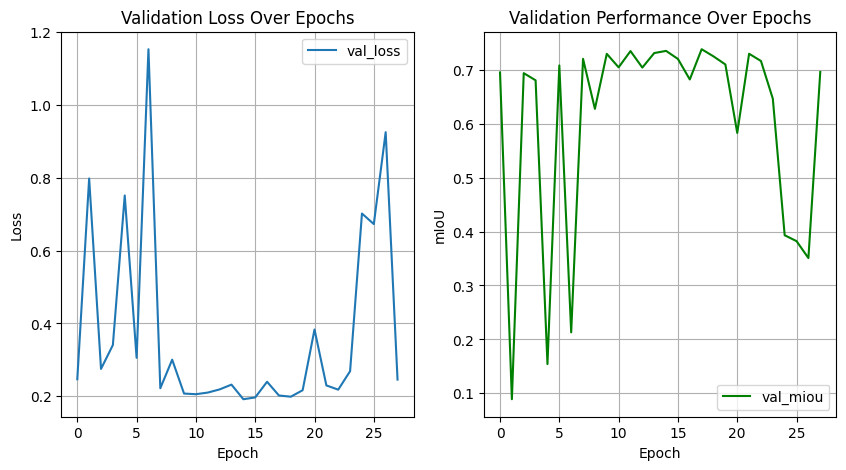

In [10]:
# Plot mIoU and loss over training epochs
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(epochs_data["epoch"], epochs_data["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss Over Epochs")
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_data["epoch"], epochs_data["val_miou"], label="val_miou", color="green")
plt.xlabel("Epoch")
plt.ylabel("mIoU")
plt.title("Validation Performance Over Epochs")
plt.grid(True)
plt.legend()

plt.show()

**TODO:** Describe the results in a few paragraphs.

The two plots above illustrate the training course. As you can see in the left graph, the training was very unstable at the beginning since there were drastic changes in the validation loss from the 0th to the 6th epoch. One possible reason for this is that the initial learning rate was set too high, causing the model to take large steps and overshoot low-loss regions. Such spikes are not necessarily bad, but not ideal either. Ideally, the loss should decrease gradually over the first few epochs. From the 7th to the 19th epoch, the loss stabilized at around 0.2. However, after the 19th epoch, the validation loss increased again, indicating that the model had started to overfit.

As shown in the right plot, the graph of the validation performance more or less mirrors the inverse of the loss. In the first epochs, the model's performance, measured with mIoU, was spiky as well. As soon as the loss began to stabilize, the performance maintained an mIoU of approximately 0.7-0.73. An increase in loss at the end resulted in a decrease in mIoU.

### 2.4.2 Qualitative Evaluation

Please visualize a few (at least 2) example outputs in the form: 1: Input Image 2: Reference Mask 3: Predicted Mask.


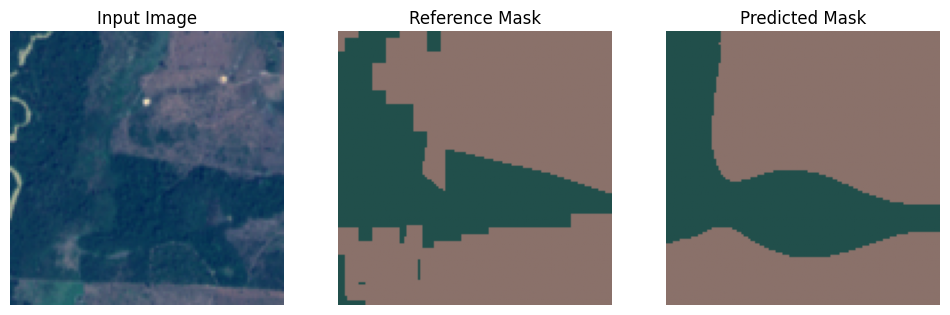

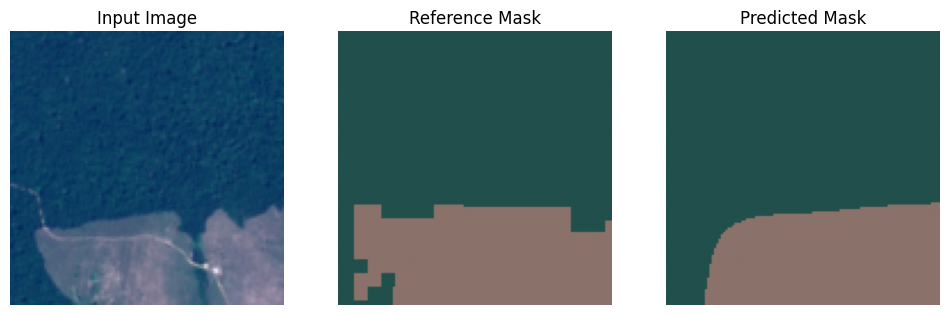

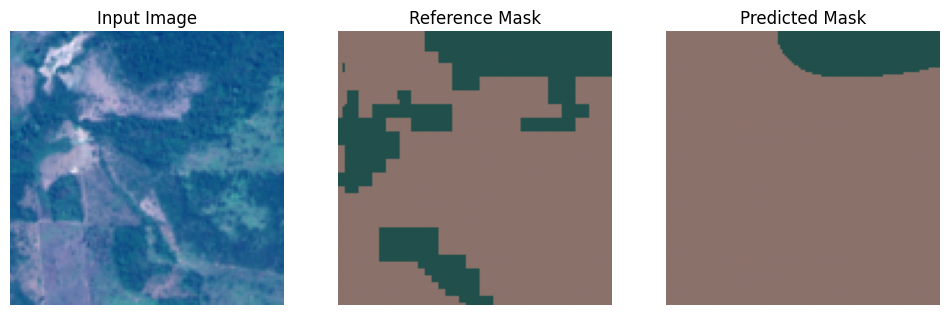

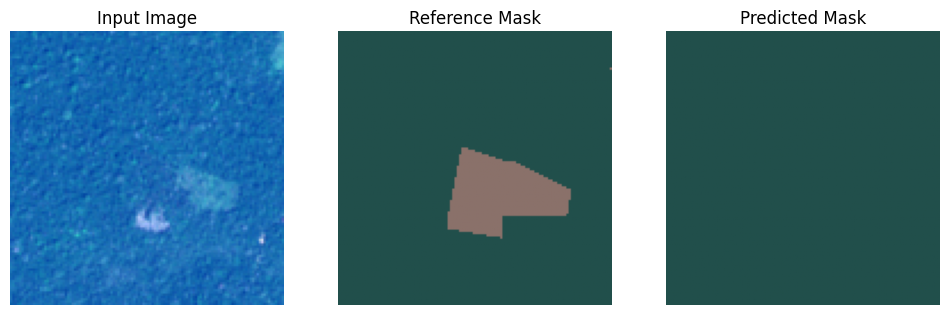

In [16]:
# Plot some (at least 2) example images
# Plot: Input Image - Reference Mask - Predicted Mask
best_model_path = checkpoint_callback.best_model_path
model = FCNResnet.load_from_checkpoint(best_model_path)
model.eval()

# Hand-picked examples from test dataset
test_dataloader = data_module.test_dataloader()
test_dataset = test_dataloader.dataset
indices = [430, 41, 21, 143,]

for idx in indices:
    img, mask = test_dataset[idx]
    # adding a batch dimension of size 1 to make it compatible with the model ((bands, height, width) --> (1, bands, height, width))
    img_batch = img.unsqueeze(0)

    with torch.no_grad():
        logits = model(img_batch)
        pred_mask = logits.argmax(dim=1).squeeze(0)

    bands = [2,1,0] # RGB (B04, B03, B02)
    img_bands = img[bands, :, :].numpy().transpose(1, 2, 0)
    img_bands = (img_bands - img_bands.min()) / (img_bands.max() - img_bands.min() + 1e-6)
    
    mask_np = mask.squeeze(0).numpy()
    pred_np = pred_mask.numpy()

    cmap = ListedColormap(["#8A716A", "#214F4B"]) # brown (no forest) and green (forest)     
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.title("Input Image")
    plt.imshow(img_bands)
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.title("Reference Mask")
    plt.imshow(mask_np, cmap=cmap, vmin=0, vmax=1)
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.title("Predicted Mask")
    plt.imshow(pred_np, cmap=cmap, vmin=0, vmax=1)
    plt.axis("off")
    
    plt.show()

**TODO:** Describe the results in a few paragraphs.

The plot shows some examples of the model's performance on images from the test dataset. For the first two images, the model recognizes general structures and broad areas of forest. However, the predicted masks do not contain all the fine details included in the reference masks, such as sharp edges or smaller clusters.

In contrast, the other two examples demonstrate poor results, where the model identified only a small fraction of forest or was not able to detect coarse shapes at all.